
--- Running augmentation: baseline ---
Files already downloaded and verified
Files already downloaded and verified
Epoch 1: Accuracy=0.5152
Epoch 2: Accuracy=0.5706
Epoch 3: Accuracy=0.5959
Epoch 4: Accuracy=0.6100
Epoch 5: Accuracy=0.6214
Epoch 6: Accuracy=0.6124
Epoch 7: Accuracy=0.6215
Epoch 8: Accuracy=0.6277
Epoch 9: Accuracy=0.6125
Epoch 10: Accuracy=0.6146
Epoch 11: Accuracy=0.6222
Epoch 12: Accuracy=0.6264
Epoch 13: Accuracy=0.6173
Epoch 14: Accuracy=0.6208
Epoch 15: Accuracy=0.6240
Epoch 16: Accuracy=0.6057
Epoch 17: Accuracy=0.6128
Epoch 18: Accuracy=0.6221
Epoch 19: Accuracy=0.6177
Epoch 20: Accuracy=0.6238
Epoch 21: Accuracy=0.6135
Epoch 22: Accuracy=0.6229
Epoch 23: Accuracy=0.6260
Epoch 24: Accuracy=0.6195
Epoch 25: Accuracy=0.6274
Epoch 26: Accuracy=0.6236
Epoch 27: Accuracy=0.6270
Epoch 28: Accuracy=0.6141
Epoch 29: Accuracy=0.6113
Epoch 30: Accuracy=0.6242
Epoch 31: Accuracy=0.6302
Epoch 32: Accuracy=0.6187
Epoch 33: Accuracy=0.6215
Epoch 34: Accuracy=0.6214
Epoch 35:

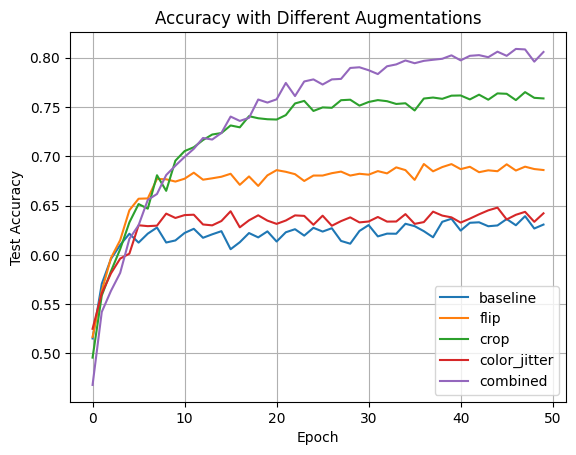


Best Augmentation: combined with Accuracy: 0.8057


In [2]:
# Vision Transformer (ViT) for CIFAR-10 based on "An Image is Worth 16x16 Words"

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np


# -------------------------------
# Patch Embedding
# -------------------------------
class PatchEmbedding(nn.Module):
    def __init__(self, img_size, patch_size, in_channels=3, emb_dim=256):
        super().__init__()
        self.patch_size = patch_size
        self.n_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, emb_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)  # shape: [B, emb_dim, H/patch, W/patch]
        x = x.flatten(2).transpose(1, 2)  # shape: [B, N_patches, emb_dim]
        return x


# -------------------------------
# Multi-Head Self-Attention
# -------------------------------
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, dim, heads=8):
        super().__init__()
        self.heads = heads
        self.head_dim = dim // heads
        self.scale = self.head_dim ** -0.5

        self.qkv = nn.Linear(dim, dim * 3)
        self.out = nn.Linear(dim, dim)

    def forward(self, x):
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]  # shape: [B, heads, N, head_dim]

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        out = (attn @ v).transpose(1, 2).reshape(B, N, D)
        return self.out(out)


# -------------------------------
# Transformer Encoder Block
# -------------------------------
class TransformerEncoderBlock(nn.Module):
    def __init__(self, dim, heads, mlp_dim):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = MultiHeadSelfAttention(dim, heads)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, mlp_dim),
            nn.GELU(),
            nn.Linear(mlp_dim, dim),
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


# -------------------------------
# Vision Transformer
# -------------------------------
class VisionTransformer(nn.Module):
    def __init__(self, img_size=32, patch_size=4, emb_dim=256, depth=6, heads=8, mlp_dim=512, n_classes=10):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, emb_dim=emb_dim)
        num_patches = (img_size // patch_size) ** 2

        self.cls_token = nn.Parameter(torch.randn(1, 1, emb_dim))
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, emb_dim))

        self.encoder = nn.Sequential(*[
            TransformerEncoderBlock(emb_dim, heads, mlp_dim) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(emb_dim)
        self.head = nn.Linear(emb_dim, n_classes)

    def forward(self, x):
        x = self.patch_embed(x)
        B, N, _ = x.shape
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x += self.pos_embed[:, :N+1]
        x = self.encoder(x)
        x = self.norm(x[:, 0])  # Use CLS token
        return self.head(x)


# -------------------------------
# Training and Evaluation
# -------------------------------
def train(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

def evaluate(model, dataloader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total




import itertools

# -------------------------------
# Run Data Augmentation Experiments
# -------------------------------
def run_augmentation_experiments():
    device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")

    augmentations = {
        "baseline": transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
        ]),
        "flip": transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
        ]),
        "crop": transforms.Compose([
            transforms.RandomCrop(32, padding=2),
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
        ]),
        "color_jitter": transforms.Compose([
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
        ]),
        "combined": transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomCrop(32, padding=2),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
        ])
    }

    best_acc = 0
    best_aug = None

    for aug_name, transform in augmentations.items():
        print(f"\n--- Running augmentation: {aug_name} ---")
        trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
        testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=augmentations["baseline"])
        trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
        testloader = DataLoader(testset, batch_size=100, shuffle=False, num_workers=2)

        model = VisionTransformer().to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
        criterion = nn.CrossEntropyLoss()

        accs = []
        for epoch in range(50):
            train(model, trainloader, optimizer, criterion, device)
            acc = evaluate(model, testloader, device)
            accs.append(acc)
            print(f"Epoch {epoch+1}: Accuracy={acc:.4f}")

        if accs[-1] > best_acc:
            best_acc = accs[-1]
            best_aug = aug_name

        plt.plot(accs, label=aug_name)

    plt.title("Accuracy with Different Augmentations")
    plt.xlabel("Epoch")
    plt.ylabel("Test Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"\nBest Augmentation: {best_aug} with Accuracy: {best_acc:.4f}")

# Run data augmentation experiments
if __name__ == '__main__':
    run_augmentation_experiments()

##  Test Accuracies:

- **Baseline:** ~63%  
- **Random Flip:** ~69%  
- **Random Crop:** ~76%  
- **Color Jitter:** ~64%  
- **Combined:** ~80.57% (best)

---

##  Analysis

The augmentation experiments demonstrate the significant impact of data augmentation techniques on ViT performance:

- **Random Crop:**  
  Provided the most substantial individual improvement (~13% over baseline), suggesting that position variation and forcing the model to focus on different parts of the image significantly improves generalization.

- **Random Flip:**  
  Offered a moderate improvement (~6%), helping the model become invariant to horizontal orientation.

- **Color Jitter:**  
  Showed minimal improvement (~1%), indicating that color perturbations alone don't significantly help the model generalize better for CIFAR-10 classification.

- **Combined Augmentation:**  
  Produced the best results with a remarkable ~17.5% improvement over baseline, achieving the target of >80% accuracy. This confirms that diverse augmentations work synergistically to improve model robustness by addressing different aspects of image variation.

---

The results align with common findings in computer vision that augmentations introducing **geometric diversity** (crops and flips) tend to be more effective than color perturbations for classification tasks.
